In [1]:
import pandas as pd

df = pd.read_csv("../../data/semiconductor_yield_forecasting_data.csv")

print("전체 행 수:", len(df))
print("전체 열 개수:", len(df.columns))

숫자형_열 = df.select_dtypes(include="number").columns
print("숫자형 열 개수:", len(숫자형_열))

print(df["yield"].value_counts())
print(df["yield"].value_counts(normalize=True).round(4))

전체 행 수: 1250
전체 열 개수: 28
숫자형 열 개수: 19
yield
0.678783    1
0.779966    1
0.778492    1
0.405275    1
0.935350    1
           ..
0.434268    1
0.566107    1
0.442415    1
0.782406    1
0.666890    1
Name: count, Length: 1250, dtype: int64
yield
0.678783    0.0008
0.779966    0.0008
0.778492    0.0008
0.405275    0.0008
0.935350    0.0008
             ...  
0.434268    0.0008
0.566107    0.0008
0.442415    0.0008
0.782406    0.0008
0.666890    0.0008
Name: proportion, Length: 1250, dtype: float64


count    1250.000000
mean        0.456679
std         0.175306
min         0.148086
25%         0.323588
50%         0.415796
75%         0.573955
max         0.982489
Name: yield, dtype: float64

yield 결측치 수: 0
yield 왜도(skewness): 0.7405


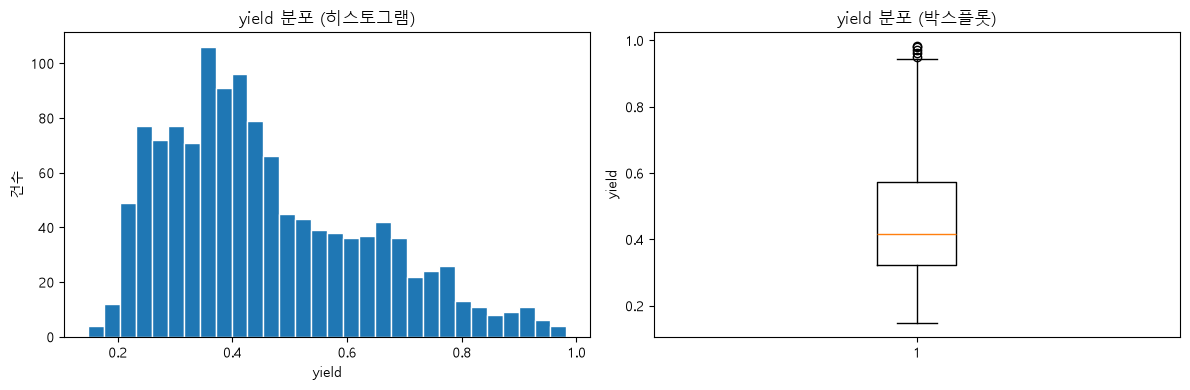

저장 완료: results/yield_distribution.png

yield와 상관관계가 높은 숫자형 열 (상위 10개):
critical_dimension     -0.652517
vth                    -0.541121
oxide_thickness        -0.507109
resistance             -0.202320
defect_count           -0.122595
thickness_uniformity   -0.122551
defect_density         -0.119366
focus_offset            0.072350
dose                    0.057008
leakage_current        -0.046530
Name: yield, dtype: float64


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# yield는 회귀의 목표값(연속형 수치)이므로, 범주별 건수 대신
# 분포 통계 + 그림 + 다른 열과의 상관관계로 살펴본다

print(df["yield"].describe())

결측치_수 = df["yield"].isna().sum()
print("\nyield 결측치 수:", 결측치_수)

왜도 = df["yield"].skew()
print("yield 왜도(skewness):", round(왜도, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["yield"], bins=30, color="tab:blue", edgecolor="white")
axes[0].set_title("yield 분포 (히스토그램)")
axes[0].set_xlabel("yield")
axes[0].set_ylabel("건수")

axes[1].boxplot(df["yield"].dropna())
axes[1].set_title("yield 분포 (박스플롯)")
axes[1].set_ylabel("yield")

plt.tight_layout()
plt.savefig("results/yield_distribution.png", dpi=150)
plt.show()

print("저장 완료: results/yield_distribution.png")

# 회귀 변수 선택에 참고할 - yield와 상관관계가 높은 숫자형 열 상위 10개
상관관계 = df[숫자형_열].corr()["yield"].drop("yield").sort_values(key=abs, ascending=False)
print("\nyield와 상관관계가 높은 숫자형 열 (상위 10개):")
print(상관관계.head(10))

# 내 프로젝트 v1

# 실습 16 - 문제 정의서

## 문제 정의

**한 문장** : [반도체 공정 파라미터의 측정값으로, 공정이 끝나기 전 확보한 계측값을 통해 수율을 예측한다]

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | [공정 엔지니어] |
| 무엇을 결정하나 | [공정 파라미터(etch_rate, pressure, temperature, exposure_time, focus_offset, dose, deposition_rate, thickness_uniformity, implant_energy, tilt_angle)로 이 로트의 yield 값을 미리 예측한다] |
| 언제 결정하나 | [공정이 진행 중이라 계측값(critical_dimension 등)이 아직 없는 시점] |
| 이 판단이 늦으면 | [불량이 다음 공정까지 넘어가고, 고객사에서 발견되면 비용이 훨씬 커진다] |

## 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | [공개 데이터(Kaggle)] |
| 규모 | [1250행 x 28열] |
| 입력으로 쓸 열 | [숫자로 된 측정 열 19개] |
| 결과 열 | [yield] |
| 결과 열의 값 | [숫자] |
| 기준선이 될 숫자 | [불합격 133건 (4.67%)] |

## 한계

- [측정값이 어느 설비에서 나온 것인지가 표에 없어서, 설비별 차이는 볼 수 없다]
- [기록된 기간이 짧아 계절이나 원료 교체 같은 긴 흐름은 담기지 않았다]
- [값이 높은 구간에서 불량이 많이 관찰되더라도, 그것이 원인이라고는 말할 수 없다]